# CREATING CLASS

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import time 
from sklearn import datasets

%matplotlib inline 

So we have y = B0 + X.B1,   B0 = intercept, B1 = slope

In [92]:
class grad_desc : 
    def __init__(self,X,Y,LR=0.1) : 
        self.X = np.array(X)
        self.Y = np.array(Y)
        self.data_point_count = X.shape[0]
        self.starter_intercept = 0
        self.starter_slope = 1
        self.LR = LR

    
    def polish_data(self): 
        X_mean = self.X.mean(axis=0)
        X_std = self.X.std(axis=0)
        X_scaled = (self.X - X_mean) / X_std
        self.X = X_scaled
        self.Y = self.Y.reshape((self.data_point_count,1))
        self.Xb = np.c_[ np.ones( shape = ((self.X.shape[0]),1)), self.X ]
        n_params = self.Xb.shape[1]
        self.B = np.zeros((n_params, 1))
       

        print(f"shape : Y : {self.Y.shape}")
        print(f"shape : Xb : {self.Xb.shape}")
        print(f"shape : B : {self.B.shape}")
        # print(f"shape : CFD : {self.cost_func_derivative.shape}")

    def next_bias(self,old_B):
        cost_func_derivative = -1/self.data_point_count*(self.Xb.T @ (self.Y - (self.Xb@old_B)))
        next_bias = old_B - self.LR*cost_func_derivative
        return next_bias
        
    def cost(self, B):
        residuals = self.Y - self.Xb @ B
        return (residuals.T @ residuals).item() / (2 * self.data_point_count)


# SINGLE PARAM

In [93]:
def plot_grad_desc(iters,X,Y,LR):
    desc = grad_desc(np.array(X), np.array(Y),LR)
    desc.polish_data()
    next_bias = desc.next_bias(desc.B)

    output = np.zeros(shape=(iters,desc.B.shape[0]))
    plt.figure(figsize=(8, 6))
    x_min, x_max = desc.X.min(), desc.X.max()
    y_min, y_max = desc.Y.min(), desc.Y.max()

    plt.xlim(x_min, x_max)          # <-- lock x-axis range
    plt.ylim(y_min - 1, y_max)  # <-- lock y-axis range (padded a bit)
    costs = []
    for i in range(iters):
        next_bias = desc.next_bias(next_bias)
        costs.append(desc.cost(next_bias))
        
        intercept, slope = next_bias.flatten()
        
        
        sns.scatterplot(x=desc.X, y=desc.Y.flatten(), alpha=0.5, s=10)
        
        x_vals = np.linspace(desc.X.min(), desc.X.max(), 100)
        y_vals = intercept + slope * x_vals
        if(i == iters-1) : 
            plt.plot(x_vals, y_vals, color='black', linewidth=2,alpha=1)
        else : 
            plt.plot(x_vals, y_vals, color='red', linewidth=1,alpha=i*1/(2*iters))

            
        plt.title(f"Iteration {i+1} | intercept={intercept:.4f}, slope={slope:.4f}")
        plt.xlabel("MedInc")
        plt.ylabel("target")
        # plt.show()
    plt.figure()
    plt.plot(costs)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("COST vs ITERATIONS")
    plt.show()
    
    

shape : Y : (20640, 1)
shape : Xb : (20640, 2)
shape : B : (2, 1)


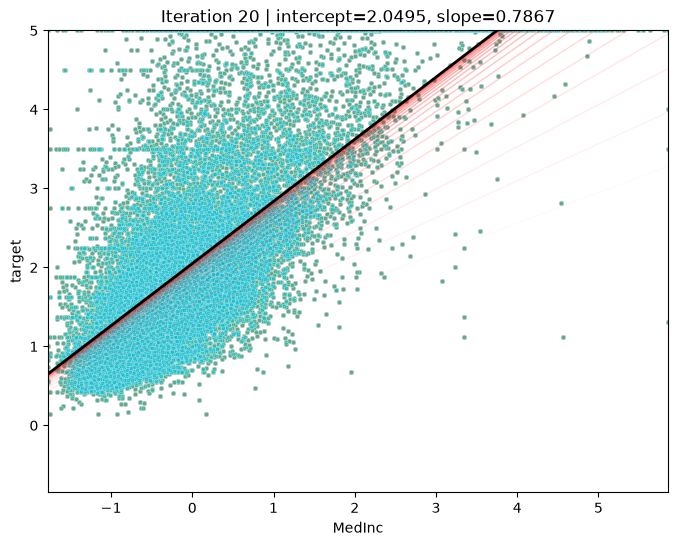

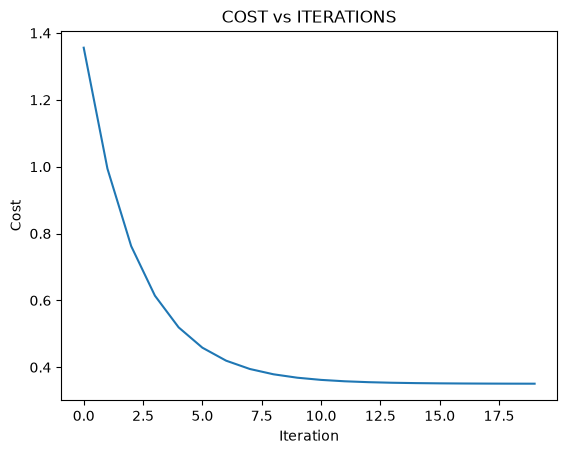

In [99]:
df = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])
X = np.array(df['MedInc'])

df['target'] = dataset['target']
Y = np.array(df['target'])

plot_grad_desc(20,X,Y,0.2)

# MULTIPLE PARAMS

In [95]:
def grad_desc_mul(iters,X,Y,LR):
    desc = grad_desc(np.array(X), np.array(Y),LR)
    desc.polish_data()
    next_bias = desc.next_bias(desc.B)
    costs = []
    
    for i in range(iters):
        next_bias = desc.next_bias(next_bias)
        print(desc.cost(next_bias))
        costs.append(desc.cost(next_bias))
    
    plt.plot(costs)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Convergence")
    plt.show()
        
    final_bias = next_bias
    return final_bias

In [96]:
def plot_actual_vs_pred(Y,X,bias) :
    X = np.c_[np.ones(shape = (X.shape[0], 1)) , X]
    Y_hat = X @ bias

    sns.scatterplot(x=np.array(Y).flatten(), y=np.array(Y_hat).flatten())


shape : Y : (20640, 1)
shape : Xb : (20640, 9)
shape : B : (9, 1)
2.0985412979611873
1.824966793313726
1.5936387569954418
1.3979672717095073
1.2324029238245011
1.0922692599581147
0.9736230917344516
0.8731377889956481
0.7880056095064258
0.7158558366469389
0.6546860765687966
0.6028045338475987
0.5587814635699376
0.5214083063458749
0.4896632651233747
0.4626822899626935
0.43973460779170365
0.420202075469834
0.4035617516941171
0.38937118074892596
0.37725596234082126
0.3668992496095697
0.3580328741723846
0.3504298446240883
0.34389800482533056
0.3382746718352053
0.3334221015332627
0.32922365369862305
0.3255805482930572
0.322409121532022


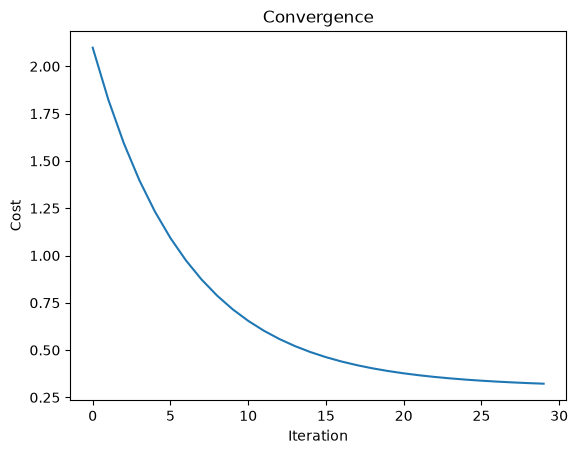

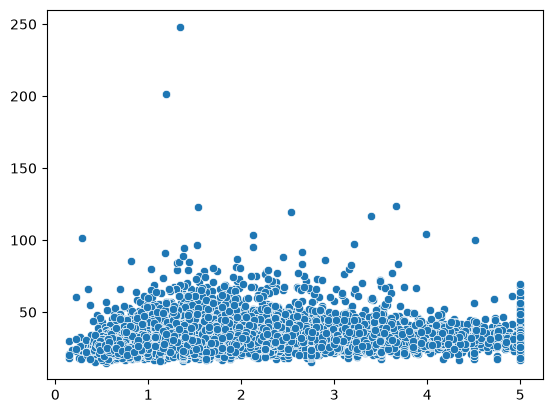

In [97]:
dataset = datasets.fetch_california_housing()
df = pd.DataFrame(data=dataset['data'], columns=dataset['feature_names'])

X = np.array(df)


df['target'] = dataset['target']
Y = np.array(df['target'])

bias = grad_desc_mul(30,X,Y,0.08)
plot_actual_vs_pred(Y,X,bias)